### PYTHON-14. Очистка данных

***

2.Знакомство с новыми данными: данные о квартирах от Сбера

В этом модуле мы с вами будем работать с данными с самого настоящего соревнования на платформе Kaggle, инициатором которого стал Сбер. Соревнование проводилось в 2017 году, его призовой фонд составил 25 000 $. Требования Сбера состояли в построении модели, которая бы прогнозировала цены на жильё в Москве, опираясь на параметры самого жилья, а также состояние экономики и финансового сектора в стране.

In [3]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
sber_data = pd.read_csv('sber_data/sber_data.csv',sep=',')
sber_data['price_doc'].sort_values(ascending=False)[:8]

2118     111111112
28326     95122496
7457      91066096
19095     80777440
6319      78802248
3557      77000000
27460     71249624
11085     71200000
Name: price_doc, dtype: int64

Задание 2.4
Проверим, влияет ли уровень экологической обстановки в районе на цену квартиры. Постройте коробчатую диаграмму цен на квартиры (price_doc) в зависимости от уровня экологической обстановки в районе (ecology). Какой уровень ценится на рынке меньше всего?

In [4]:
sber_data_copy = sber_data.copy()
sber_data_box = sber_data_copy.pivot_table(values='price_doc', index = 'ecology', aggfunc='count')
display(sber_data_box)
#sber_data_copy_box.plot(kind='box',figsize=(12,4),title = '', grid = True, lw= 3)

,price_doc
ecology,
excellent,3938
good,7174
no data,7656
poor,8018
satisfactory,3685


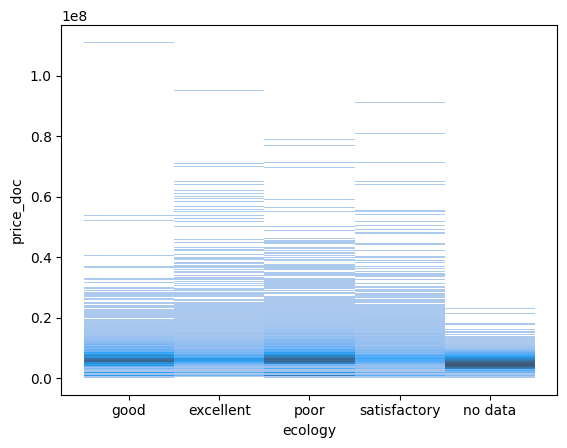

In [45]:
rgion_plot = sns.histplot(data=sber_data_copy, x = 'ecology', y = 'price_doc', kde = True)

Задание 2.5
Постройте диаграмму рассеяния, которая покажет, как цена на квартиру (price_doc) связана с расстоянием до центра Москвы (kremlin_km). Выберите все верные утверждения.

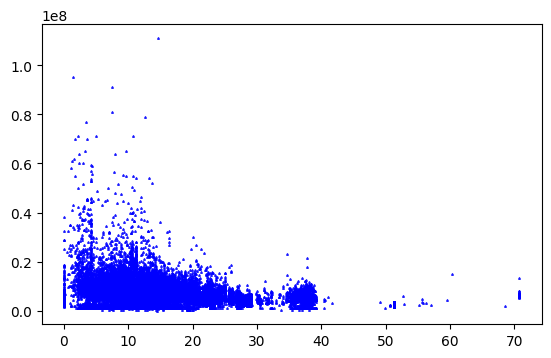

In [49]:
fig = plt.figure(figsize=(5, 3))
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(
    x=sber_data_copy['kremlin_km'], 
    y=sber_data_copy['price_doc'], 
    s=1,
    marker='^',
    c = 'blue' );

#### ПРАКТИКА УДАЛЕНИЯ СТРОК ИЗ ТАБЛИЦЫ С ПРОПУСКАМИИ ЗНАЧЕНИЙ 
Предварительно создадим копию исходной таблицы — drop_data, чтобы не повредить её. Зададимся порогом в 70 %: будем оставлять только те столбцы, в которых 70 и более процентов записей не являются пустыми . После этого удалим записи, в которых содержится хотя бы один пропуск. Наконец, выведем информацию о числе пропусков и наслаждаемся нулями. 

In [ ]:
sber_data_drop = sber_data_copy.copy()

#задаем минимальный порог: вычисляем 70% от числа строк
thresh = sber_data_drop.shape[0]*0.7 

#удаляем столбцы, в которых более 30% (100-70) пропусков
sber_data_drop = sber_data_drop.dropna(thresh=thresh, axis=1)

#удаляем записи, в которых есть хотя бы 1 пропуск
sber_data_drop = sber_data_drop.dropna(how = 'any', axis = 0)

#отображаем результирующую долю пропусков
sber_data_drop.isnull().mean()

print(sber_data_drop.shape)

# Итак, мы удалили один столбец и ⅓ всех записей для того, 
# чтобы избавиться от пропусков. Не слишком ли это много и что с этим можно сделать?

(20888, 60)


### Заполнение недостающих значений константами

Чтобы дырявая бочка не протекала, вставьте в дырку пробку. С этой мыслью связан другой способ бороться с пропусками — заполнение константами. 

Чаще всего пустые места заполняют средним/медианой/модой для числовых признаков и модальным значением для категориальных признаков. 

array([[<Axes: title={'center': 'life_sq'}>,
        <Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'preschool_quota'}>],
       [<Axes: title={'center': 'school_quota'}>,
        <Axes: title={'center': 'hospital_beds_raion'}>,
        <Axes: title={'center': 'metro_min_walk'}>],
       [<Axes: title={'center': 'metro_km_walk'}>,
        <Axes: title={'center': 'railroad_station_walk_km'}>,
        <Axes: title={'center': 'railroad_station_walk_min'}>]],
      dtype=object)

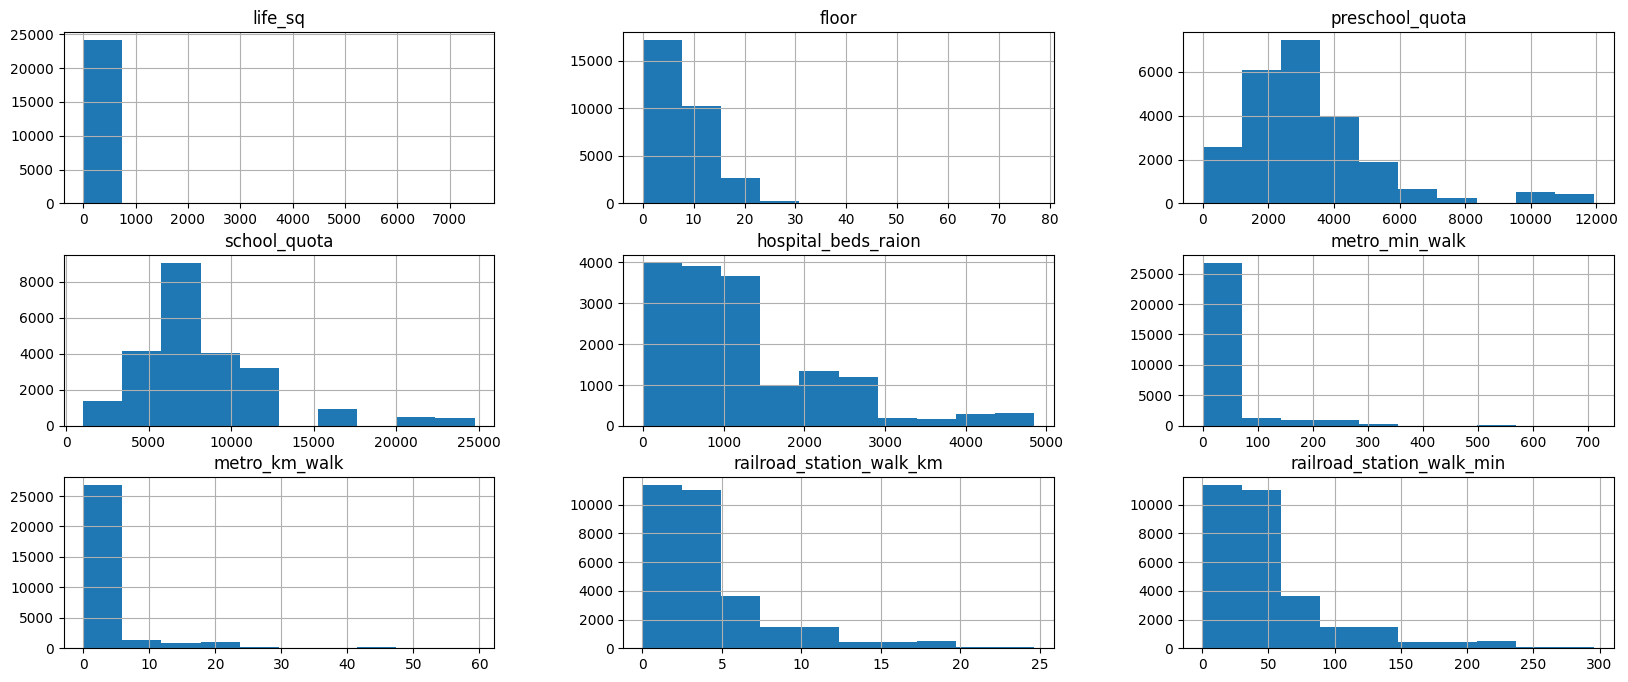

In [ ]:
# Вся сложность заключается в выборе метода заполнения. 
# Важным фактором при выборе метода является распределение признаков с пропусками. Давайте выведем их на экран. 

# делаем маску для проверки у кого есть пропуски 
cols_with_null = sber_data_copy.isnull().sum() 
# отбираем те, которые содержат пропуски, по количеству они должны быть отличны от нуля. 
cols_with_null = cols_with_null[cols_with_null>0]
# строим график 
cols = cols_with_null.index
sber_data_copy[cols].hist(figsize=(20,8))

Заполнение значений осуществляется с помощью метода fillna(). Главный параметр метода — value (значение, на которое происходит заполнение данных в столбце). Если метод вызывается от имени всего DataFrame, то в качестве value можно использовать словарь, где ключи — названия столбцов таблицы, а значения словаря — заполняющие константы. 

Создадим такой словарь, соблюдая рекомендации, приведённые выше, а также копию исходной таблицы. Произведём операцию заполнения с помощью метода fillna() и удостоверимся, что пропусков в данных больше нет:

In [ ]:
#создаем копию исходной таблицы
fill_data = sber_data.copy()

# создаем словарь имя столбца: число(признак) на который надо заменить пропуски 
values = {'life_sq': fill_data['full_sq'], 'metro_min_walk': fill_data['metro_min_walk'].median(),
          'metro_km_walk': fill_data['metro_km_walk'].median(), 
          'railroad_station_walk_km':fill_data['railroad_station_walk_km'].median(), 
          'railroad_station_walk_min':fill_data['railroad_station_walk_min'].median(),
          'hospital_beds_raion':fill_data['hospital_beds_raion'].mode()[0], 
          'school_quota':fill_data['school_quota'].mode()[0],
          'floor':fill_data['floor'].mode()[0]}
# заполняем пропуски в соответствие с заявленным словарем 
fill_data = fill_data.fillna(values)
# выводим результирующую долю пропусков 
fill_data.isnull().mean() 

id                   0.0
full_sq              0.0
life_sq              0.0
floor                0.0
sub_area             0.0
                    ... 
theater_km           0.0
museum_km            0.0
ecology              0.0
mosque_count_1000    0.0
price_doc            0.0
Length: 61, dtype: float64

array([[<Axes: title={'center': 'preschool_quota'}>]], dtype=object)

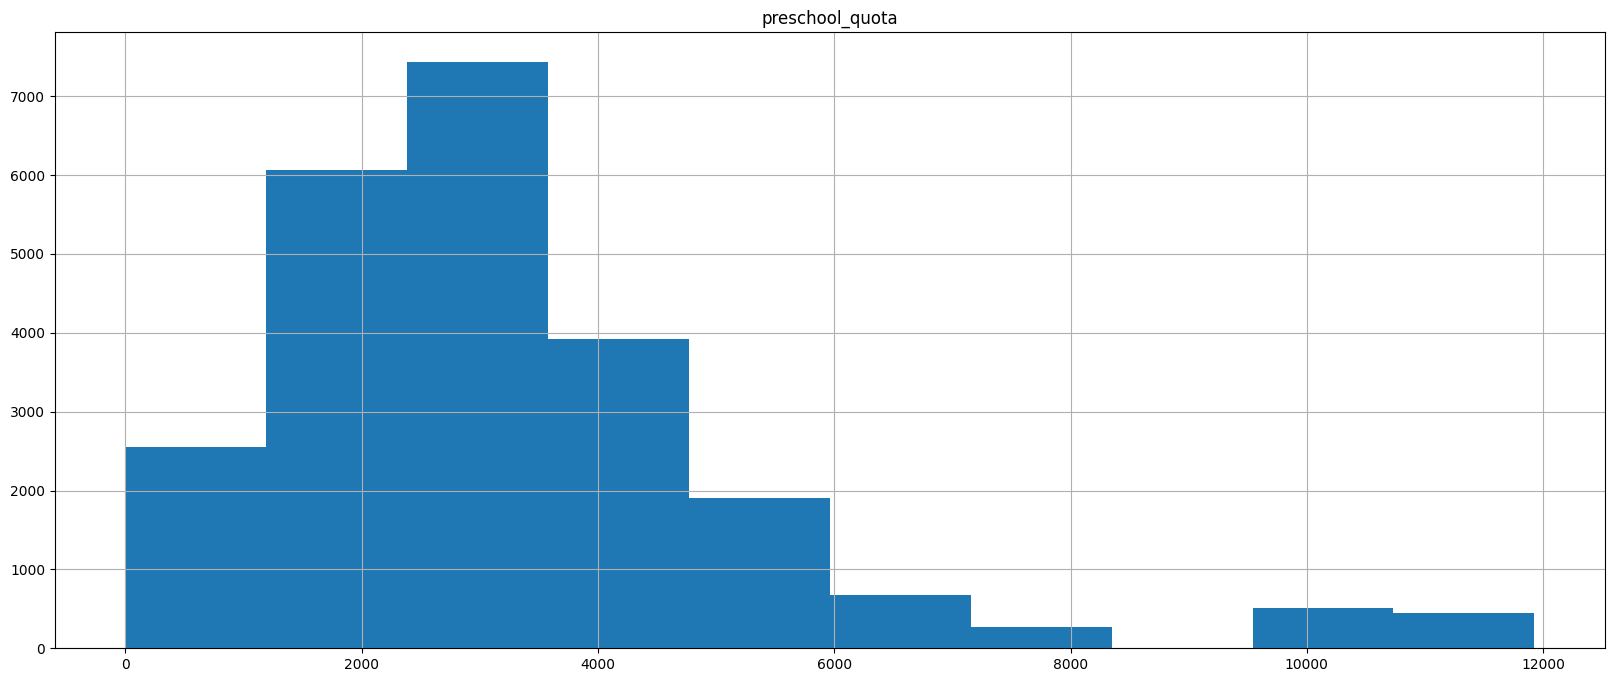

In [67]:
cols_with_null = fill_data.isnull().sum() 
# отбираем те, которые содержат пропуски, по количеству они должны быть отличны от нуля. 
cols_with_null = cols_with_null[cols_with_null>0]
# строим график 
cols = cols_with_null.index
fill_data[cols].hist(figsize=(20,8))

Давайте добавим к нашим данным признаки-индикаторы, которые будут сигнализировать о том, что в столбце на определённом месте в таблице был пропуск. Это место в столбце-индикаторе будем помечать как True. 

Посмотрим на реализацию. Как обычно, создадим копию indicator_data исходной таблицы. В цикле пройдёмся по столбцам с пропусками и будем добавлять в таблицу новый признак (с припиской "was_null"), который получается из исходного с помощью применения метода isnull(). После чего произведём обычное заполнение пропусков, которое мы совершали ранее, и выведем на экран число отсутствующих значений в столбце, чтобы убедиться в результате:

In [72]:
# создаем копию исходной таблицы 
indicator_data = sber_data.copy()
cols_with_null_2 = indicator_data.isnull().sum() 
# отбираем те, которые содержат пропуски, по количеству они должны быть отличны от нуля. 
cols_with_null_2 = cols_with_null_2[cols_with_null_2>0]

# в цикле пробегаем по названию стобцов с пропусками 
for col in cols_with_null_2.index: 
    # создаем новый признак-индикатор как col_was_null 
    indicator_data[col + '_was_null'] = indicator_data[col].isnull()
    
# создаем словарь имя стобца: число(признак) на который надо заменить пропуски
values = {'life_sq': fill_data['full_sq'], 'metro_min_walk': fill_data['metro_min_walk'].median(),
          'metro_km_walk': fill_data['metro_km_walk'].median(), 
          'railroad_station_walk_km':fill_data['railroad_station_walk_km'].median(), 
          'railroad_station_walk_min':fill_data['railroad_station_walk_min'].median(),
          'hospital_beds_raion':fill_data['hospital_beds_raion'].mode()[0], 
          'school_quota':fill_data['school_quota'].mode()[0],
          'floor':fill_data['floor'].mode()[0]}
# заполняем пропуски в соответствии с заявленным словарем 
indicator_data = indicator_data.fillna(values)
# выводим результирующую долю пропусков 
# indicator_data.isnull().mean().nlargest(10)

fill_data.head(7)

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,theater_km,museum_km,ecology,mosque_count_1000,price_doc
0,1,43,27.0,4.0,Bibirevo,5001.0,5,11065.0,5,0,...,0.637189,0.947962,0.177975,0.625783,0.628187,14.053047,7.389498,good,0,5850000
1,2,34,19.0,3.0,Nagatinskij Zaton,3119.0,5,6237.0,8,0,...,0.688796,1.072315,0.273345,0.967821,0.471447,6.829889,0.709260,excellent,0,6000000
2,3,43,29.0,2.0,Tekstil'shhiki,1463.0,4,5580.0,7,0,...,1.543049,0.391957,0.158072,3.178751,0.755946,4.273200,3.156423,poor,0,5700000
3,4,89,50.0,9.0,Mitino,6839.0,9,17063.0,10,0,...,0.934273,0.892674,0.236455,1.031777,1.561505,16.990677,16.041521,good,0,13100000
4,5,77,77.0,4.0,Basmannoe,3240.0,7,7770.0,9,0,...,0.077901,0.810801,0.376838,0.378756,0.121681,1.112486,1.800125,excellent,0,16331452
5,6,67,46.0,14.0,Nizhegorodskoe,852.0,2,2012.0,3,0,...,0.422358,3.066285,0.113466,0.686932,0.870447,3.388810,3.713557,poor,0,9100000
6,7,25,14.0,10.0,Sokol'niki,933.0,5,5050.0,5,0,...,0.067725,0.273019,0.516979,0.822377,0.318230,0.752223,2.969315,poor,0,5500000


### Комбинирование методов
Наверняка вы уже догадались, что необязательно использовать один метод. Вы можете их комбинировать. Например, мы можем:

удалить столбцы, в которых более 30 % пропусков;
удалить записи, в которых более двух пропусков одновременно;
заполнить оставшиеся ячейки константами.
Посмотрим на реализацию такого подхода в коде:



In [75]:
#  создаем копию таблицы 
combine_data = sber_data.copy()

# отбрасываем столбцы с числом пропусков более 30% (100-70)
n = combine_data.shape[0] # число строк в таблице 
thresh = n*0.7 
combine_data = combine_data.dropna(thresh=thresh, axis = 1) 

# отбрасываем строки с числом пропусков более 2 в строке 
m=combine_data.shape[1] # число признаков после удаления стобцов 
combine_data = combine_data.dropna(thresh = m-2, axis = 0)

# создаем словарь 'имя стобца': число(признак) на который надо заменить пропуски
values = {'life_sq': fill_data['full_sq'], 'metro_min_walk': fill_data['metro_min_walk'].median(),
          'metro_km_walk': fill_data['metro_km_walk'].median(), 
          'railroad_station_walk_km':fill_data['railroad_station_walk_km'].median(), 
          'railroad_station_walk_min':fill_data['railroad_station_walk_min'].median(),
          'hospital_beds_raion':fill_data['hospital_beds_raion'].mode()[0], 
          'school_quota':fill_data['school_quota'].mode()[0],
          'floor':fill_data['floor'].mode()[0]}

# заполняем оставшиеся записи константами в соответствие со словарем values
combine_data = combine_data.fillna(values)
# выводим результирующую долю пропусков 
display(combine_data.isnull().mean())


id                                       0.000000
full_sq                                  0.000000
life_sq                                  0.000000
floor                                    0.000000
sub_area                                 0.000000
preschool_quota                          0.113396
preschool_education_centers_raion        0.000000
school_quota                             0.000000
school_education_centers_raion           0.000000
school_education_centers_top_20_raion    0.000000
healthcare_centers_raion                 0.000000
university_top_20_raion                  0.000000
sport_objects_raion                      0.000000
additional_education_raion               0.000000
culture_objects_top_25_raion             0.000000
shopping_centers_raion                   0.000000
office_raion                             0.000000
oil_chemistry_raion                      0.000000
railroad_terminal_raion                  0.000000
nuclear_reactor_raion                    0.000000


In [76]:
print(combine_data.shape)

(26800, 60)


Задание 4.6
Вам предоставлен файл test_data.csv. Прочитав этот файл, вы получите вот такой DataFrame:
Ваша задача — очистить данную таблицу от пропусков следующим образом:

Если признак имеет больше 50% пропущенных значений, удалите его.
Для оставшихся данных: если в строке более двух пропусков, удалите строку.
Для оставшихся данных: числовые признаки заполните средним значением, а категориальные — модой.
У вас должна получиться следующая таблица df:
Примечание. Не забудьте импортировать библиотеки.

In [87]:
import pandas as pd 
data = pd.read_csv('data.csv')
data = data.dropna(thresh = 4, axis = 1)

data = data.dropna(thresh = 3, axis = 0)
data_values = {'one':data['one'].mean(), 'two':data['two'].mean(),'three':data['three'].mean(), 
               'four':data['four'].mode()[0]}

data = data.fillna(data_values)
data

,index,one,two,three,four
0,a,1.331587,0.715279,-1.545400,bar
2,c,-0.008384,0.621336,-0.720086,bar
3,d,1.000000,0.500000,0.500000,bar
4,e,0.265512,0.108549,0.004291,bar
5,f,-0.174600,0.433026,1.203037,bar
6,g,0.241508,0.567744,1.200000,hist
7,h,-0.965066,1.028274,0.228630,bar


### Методы выявления выбросов

Метод ручного поиска и здравого смысла



Пусть у нас есть признак, по которому мы будем искать выбросы. Давайте рассчитаем его статистические показатели (минимум, максимум, среднее, квантили) и по ним попробуем определить наличие аномалий.

Сделать это можно с помощью уже знакомого вам метода describe(). Рассчитаем статистические показатели для признака жилой площади (life_sq).

In [89]:
sber_data_copy['life_sq'].describe()

count    24088.000000
mean        34.403271
std         52.285733
min          0.000000
25%         20.000000
50%         30.000000
75%         43.000000
max       7478.000000
Name: life_sq, dtype: float64

Что нам говорит метод describe()? Во-первых, у нас есть квартиры с нулевой жилой площадью. Во-вторых, в то время как 75-й квантиль равен 43, максимум превышает 7 тысяч квадратных метров (целый дворец, а не квартира!). 

Найдём число квартир с нулевой жилой площадью:

In [ ]:
# Найдём число квартир с нулевой жилой площадью: 
print(sber_data_copy[sber_data_copy['life_sq']==0].shape[0])

45


А теперь выведем здания с жилой площадью более 7 000 квадратных метров:



In [92]:
sber_data_copy[sber_data_copy['life_sq']>7000]

,id,full_sq,life_sq,floor,sub_area,preschool_quota,preschool_education_centers_raion,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,...,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,theater_km,museum_km,ecology,mosque_count_1000,price_doc
13546,13549,79,7478.0,8.0,Poselenie Voskresenskoe,NaN,0,NaN,0,0,...,5.072389,1.210613,0.826052,1.582378,0.756119,21.472421,14.917332,no data,0,7705000


Логичен вопрос: а много ли у нас таких квартир, у которых жилая площадь больше, чем суммарная?

In [95]:
outliers = sber_data_copy[sber_data_copy['life_sq']>sber_data_copy['full_sq']]
print(outliers.shape[0])

37


Таких квартир оказывается 37 штук. Подобные наблюдения уже не поддаются здравому смыслу — они являются ошибочными, и от них стоит избавиться. Для этого можно воспользоваться методом drop() и удалить записи по их индексам:

In [96]:
cleaned = sber_data_copy.drop(outliers.index, axis = 0)
print(f'РЕзультирующее число записей:{cleaned.shape[0]}')

РЕзультирующее число записей:30434


### Метод межквартильного размаха (метод Тьюки)
Отличным помощником в поиске потенциальных выбросов является визуализация. Если признак является числовым, то можно построить гистограмму или коробчатую диаграмму, чтобы найти аномалии.

На гистограмме мы можем увидеть потенциальные выбросы как низкие далеко отстоящие от основной группы столбцов «пеньки», а на коробчатой диаграмме — точки за пределами усов.

✍️ Построим гистограмму и коробчатую диаграмму для признака полной площади (full_sq):

Text(0.5, 1.0, 'Full Square Distribution')

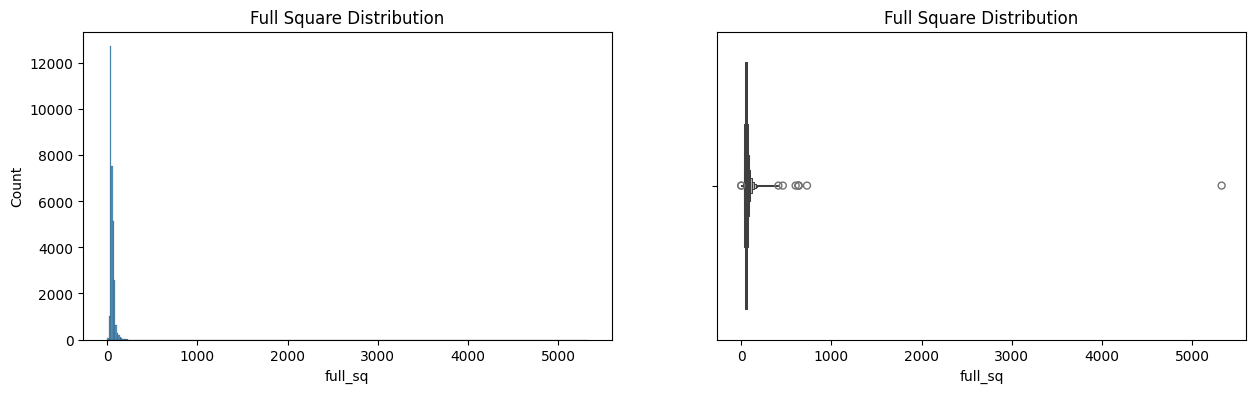

In [105]:
import matplotlib.pyplot as plt 
import seaborn as sns 

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns. histplot(data = sber_data_copy, x = 'full_sq', ax= axes[0])
histplot.set_title('Full Square Distribution')
boxplot = sns.boxenplot(data = sber_data_copy, x = 'full_sq', ax = axes [1])
boxplot.set_title('Full Square Distribution')

Врага нужно знать в лицо! Запомните эти картинки: именно так выглядят типичные графики распределений с выбросами в данных. Гистограмма, реализованная в seaborn, автоматически выбирает число столбцов, необходимое для наилучшей визуализации распределения. Когда признак содержит выбивающиеся значения, число столбцов становится очень велико и в итоге получается такая «кракозябра». 

По этой же причине получается сплюснутая под весом выбросов коробчатая диаграмма. Она помогает более чётко увидеть потенциальные аномалии, которые находятся за пределами усов (1.5 межквартильных размаха).

Основная масса квартир имеет общую площадь менее 250 квадратных метров, и лишь несколько невзрачных наблюдений выбиваются из этого интервала. Максимальная площадь, судя по гистограмме, превышает 5 000 квадратных метров.


Визуализация помогает определить наличие выбросов. Для того чтобы их найти, можно воспользоваться статистическими подходами. 

Одним из таких подходов является метод межквартильного размаха (его еще называют методом Тьюки), который используется для построения коробчатой диаграммы.

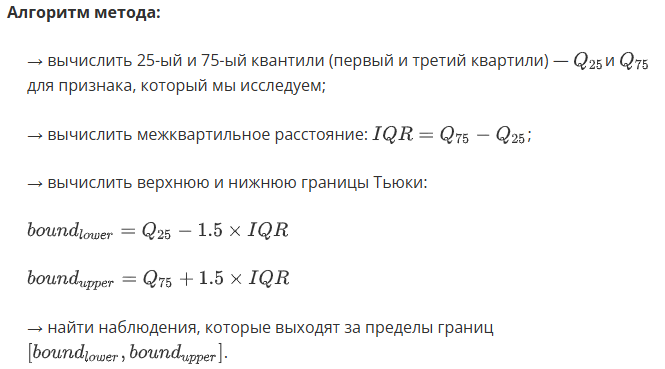

В соответствии с этим алгоритмом напишем функцию outliers_iqr(), которая вам может ещё не раз пригодиться в реальных задачах. Эта функция принимает на вход DataFrame и признак, по которому ищутся выбросы, а затем возвращает потенциальные выбросы, найденные с помощью метода Тьюки, и очищенный от них датасет.

Квантили вычисляются с помощью метода quantile(). Потенциальные выбросы определяются при помощи фильтрации данных по условию выхода за пределы верхней или нижней границы.

In [112]:
def outliers_iqr(data,feature): 
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr  = quartile_3 - quartile_1 
    lower_bound = quartile_1 - (iqr*1.5)
    upper_bound = quartile_3 + (iqr*1.5)
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned



✍️ Применим эту функцию к таблице sber_data и признаку full_sq, а также выведем размерности результатов:

In [113]:
outliers, cleaned = outliers_iqr(sber_data_copy, 'full_sq')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 963
Результирующее число записей: 29508


Согласно классическому методу Тьюки, под выбросы у нас попали 963 записи в таблице. Давайте построим гистограмму и коробчатую диаграмму на новых данных cleaned_sber_data:

Построим опять графика 

Text(0.5, 1.0, 'Cleaned Square Distribution')

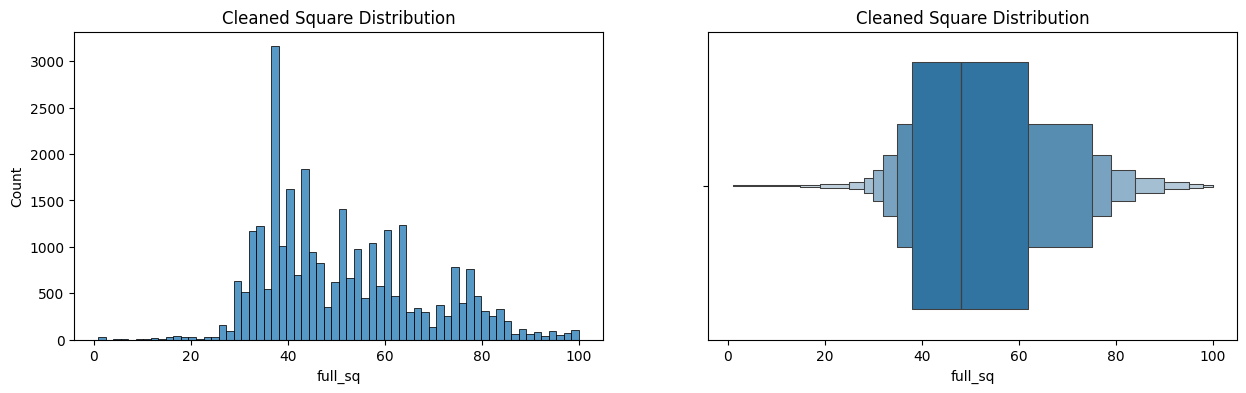

In [116]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns. histplot(data = cleaned, x = 'full_sq', ax= axes[0])
histplot.set_title('Cleaned Square Distribution')
boxplot = sns.boxenplot(data = cleaned, x = 'full_sq', ax = axes [1])
boxplot.set_title('Cleaned Square Distribution')

На первый взгляд — стерильно. Однако если присмотреться, то коробчатая диаграмма всё ещё продолжает говорить, что в данных есть одиночные выбросы с обеих сторон от границ. К тому же у нас сильно урезался диапазон жилой площади — максимальная площадь составляет около 100 кв. м. 

?
Как же так, неужели метод не работает?

Причина кроется в том, что после удаления выбросов квартили рассчитываются заново по новым данным, и так оказалось, что из-за свойств распределения были снова найдены точки, которые считаются выбросами.

Классический метод межквартильного размаха не учитывает особенностей распределения! Он требует, чтобы данные были распределены плюс-минус нормально (гистограмма должна быть похожа на колокол) и требует от распределения примерной симметричности (чтобы у гистограммы были одинаковые хвосты в обе стороны).

У нас же распределение (даже после отсечения выбросов) отличается от заявленных критериев. Оно несимметрично: правый хвост изначального распределения гораздо длиннее левого (для Москвы вполне естественны квартиры с площадью свыше 100 квадратных метров) и вовсе не колоколообразно. Попросту говоря, выбор метода поиска не оправдал себя.

### Практика 

Задание 6.1 (External resource)

Давайте немного модифицируем функцию outliers_iqr(data, feature). Добавьте в неё параметры left и right, которые задают число IQR влево и вправо от границ ящика (пусть по умолчанию они равны 1.5). Функция, как и раньше, должна возвращать потенциальные выбросы и очищенный DataFrame.

Назовите измененную функцию: outliers_iqr_mod`

Можете протестировать работу функции на DataFrame test_sber_data.csv.

In [156]:
def outliers_iqr_mod(data,feature,left=1.5,right=1.5): 
    data= pd.read_csv(data)
    x = data[feature]
         
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr  = quartile_3*right - quartile_1*left 
    lower_bound = quartile_1 - (iqr*left)
    upper_bound = quartile_3 + (iqr*right)
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned

#outliers, cleaned = outliers_iqr_mod(sber_data_copy, 'full_sq')
outliers_iqr_mod(data = 'sber_data/sber_data.csv', feature = 'full_sq')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')


Число выбросов по методу Тьюки: 482
Результирующее число записей: 29989


Задание 6.2
1 point possible (graded)
Давайте ослабим границы метода Тьюки справа и усилим их влево. Примените модифицированную функцию outliers_iqr_mod() к признаку full_sq из таблицы sber_data данным с параметрами left=1 и right=6. Результаты работы поместите в переменные outliers и cleaned. Чему равно результирующее число выбросов в данных?

In [201]:
# чуть переписал функцию с под пример, потому что у меня на изначальном датасете 'sber_data/sber_data.csv' 
# не получается увидеть релевантный результат. 
def outliers_iqr_mod_2(data,feature,left=1.5,right=1.5): 
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr  = quartile_3 - quartile_1 
    lower_bound = quartile_1 - (iqr*left)
    upper_bound = quartile_3 + (iqr*right)
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned
outliers_2, cleaned_2=outliers_iqr_mod_2(data = sber_data_copy, feature = 'full_sq',left=1,right=6)
print(f'Число выбросов по методу Тьюки: {outliers_2.shape[0]}')
print(f'Результирующее число записей: {cleaned_2.shape[0]}')


Число выбросов по методу Тьюки: 59
Результирующее число записей: 30412


Если мы построим гистограмму и коробчатую диаграмму на полученных данных, то увидим вот такую картинку:

Text(0.5, 1.0, 'Cleaned Square Distribution')

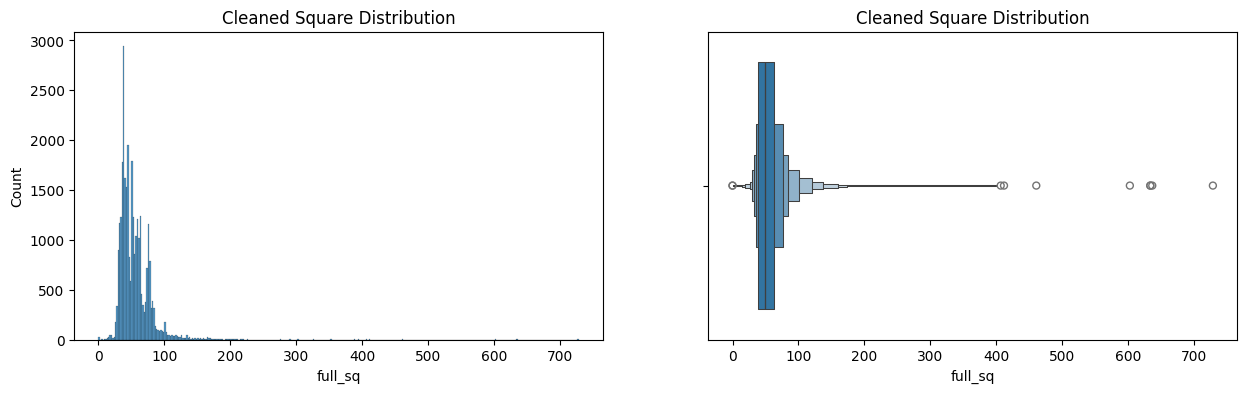

In [159]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns. histplot(data = cleaned_2, x = 'full_sq', ax= axes[0])
histplot.set_title('Cleaned Square Distribution')
boxplot = sns.boxenplot(data = cleaned_2, x = 'full_sq', ax = axes [1])
boxplot.set_title('Cleaned Square Distribution')

In [ ]:
churn_data_copy

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ClientOrNot
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Client
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,NotClient
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Client
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NotClient
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,NotClient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,NotClient
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,NotClient
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,Client
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,Client


#### Метод z-отклонений (метод сигм)



✍️ Рассмотрим логарифмирование на примере. 

Построим две гистограммы признака расстояния до МКАД (mkad_km): первая — в обычном масштабе, а вторая — в логарифмическом. Логарифмировать будем с помощью функции log() из библиотеки numpy (натуральный логарифм — логарифм по основанию числа e). Признак имеет среди своих значений 0. Из математики известно, что логарифма от 0 не существует, поэтому мы прибавляем к нашему признаку 1, чтобы не логарифмировать нули и не получать предупреждения.


Text(0.5, 1.0, 'Логарифмический расчет расстояния до МКАД')

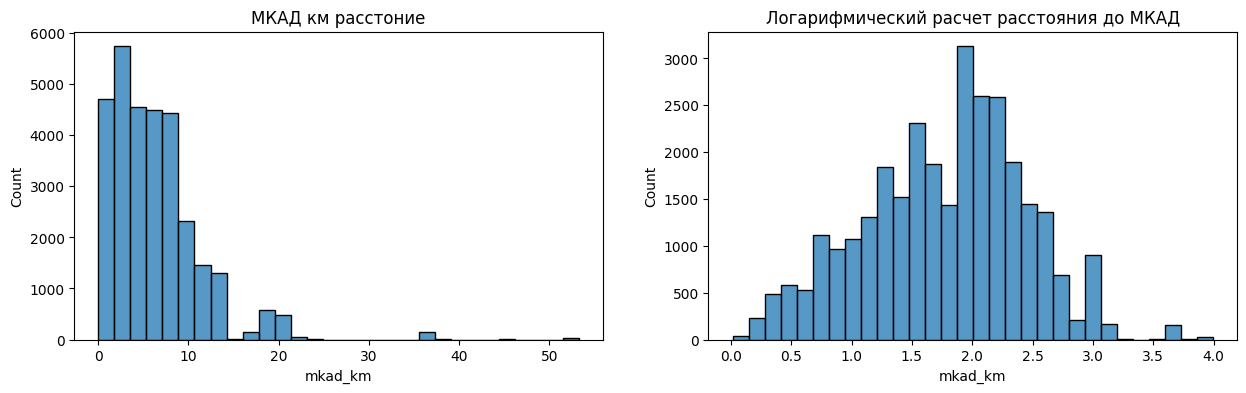

In [163]:
fig, axes = plt.subplots(1,2, figsize = (15,4))
# гистограмма исходного признака 
histplot = sns.histplot(sber_data_copy['mkad_km'], bins =30, ax = axes[0])
histplot.set_title('МКАД км расстоние')

# гистограмма в логарифмическом масштабе 
log_mkad_km = np.log(sber_data_copy['mkad_km']+1)
histplot = sns.histplot(log_mkad_km, bins = 30, ax = axes[1])
histplot.set_title('Логарифмический расчет расстояния до МКАД')


Что мы тут видим? 

Левое распределение напоминает логнормальное распределение с наличием потенциальных выбросов-«пеньков», далеко отстоящих от основной массы наблюдений.

Взяв натуральный логарифм от левого распределения, мы получаем правое, которое напоминает слегка перекошенное нормальное. Слева от моды (самого высокого столбика) наблюдается чуть больше наблюдений, нежели справа. По-научному это будет звучать так: «распределение имеет левостороннюю асимметрию».

Давайте реализуем алгоритм метода z-отклонения. Описание алгоритма метода:
→ вычислить математическое ожидание  (среднее) и стандартное отклонение  признака X;
→ вычислить нижнюю и верхнюю границу интервала как:
BOUND lower = u -3g
BOUND upper = u +3g
→ найти наблюдения, которые выходят за пределы границ.

✍️ Напишем функцию outliers_z_score(), которая реализует этот алгоритм. 

На вход она принимает DataFrame и признак, по которому ищутся выбросы. В дополнение добавим в функцию возможность работы в логарифмическом масштабе: для этого введём аргумент log_scale. Если он равен True, то будем логарифмировать рассматриваемый признак, иначе — оставляем его в исходном виде.

In [166]:
def outliers_z_scores(data, feature, log_scale = False): 
    if log_scale: x = np.log(data[feature]+1)
    else: x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - 3*sigma
    upper_bound = mu + 3*sigma
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned 


# Применим эту функцию к таблице sber_data и признаку mkad_km, а также выведем размерности результатов: 

outliers_3, cleaned_3=outliers_z_scores(data = sber_data_copy, feature = 'mkad_km',log_scale=True)
print(f'Число выбросов по методу z- отклонений: {outliers_3.shape[0]}')
print(f'Результирующее число записей: {cleaned_3.shape[0]}')

Число выбросов по методу z- отклонений: 33
Результирующее число записей: 30438


Итак, метод z-отклонения нашел нам 33 потенциальных выброса по признаку расстояния до МКАД. Давайте узнаем, в каких районах (sub_area) представлены эти квартиры

In [169]:
print(outliers_3['sub_area'].unique())

<StringArray>
['Poselenie Rogovskoe', 'Poselenie Kievskij']
Length: 2, dtype: str


In [162]:
sber_data_copy['mkad_km'].info()

<class 'pandas.Series'>
RangeIndex: 30471 entries, 0 to 30470
Series name: mkad_km
Non-Null Count  Dtype  
--------------  -----  
30471 non-null  float64
dtypes: float64(1)
memory usage: 238.2 KB


✏️ Возможно, мы не учли того факта, что наш логарифм распределения всё-таки не идеально нормален и в нём присутствует некоторая асимметрия. Возможно, стоит дать некоторое «послабление» на границы интервалов? Давайте отдельно построим гистограмму прологарифмированного распределения, а также отобразим на гистограмме вертикальные линии, соответствующие среднему (центру интервала в методе трёх сигм) и границы интервала . Вертикальные линии можно построить с помощью метода axvline(). Для среднего линия будет обычной, а для границ интервала — пунктирной (параметр ls ='--'):

Text(0.5, 1.0, 'Логарифмическое распределение расстояния до МКАД')

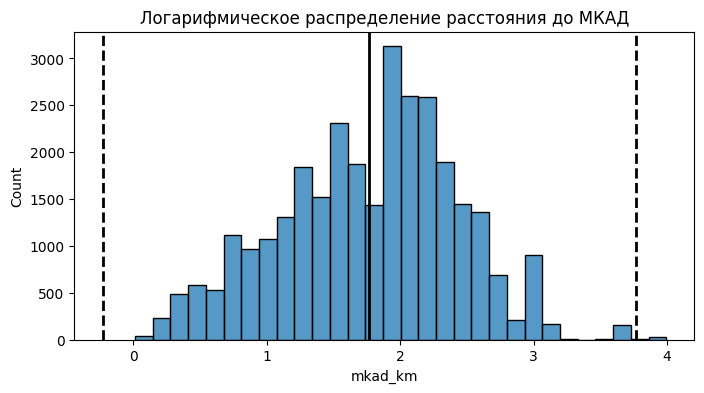

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(1, 1, figsize = (8,4))
log_mkad_km = np.log(sber_data_copy['mkad_km']+1)
histplot = sns.histplot(log_mkad_km, bins=30, axes=ax)
histplot.axvline(log_mkad_km.mean(), color = 'k', lw =2)
histplot.axvline(log_mkad_km.mean() + 3 * log_mkad_km.std(), color = 'k', ls = '--',lw =2)
histplot.axvline(log_mkad_km.mean() - 3 * log_mkad_km.std(), color = 'k', ls = '--',lw =2)
histplot.set_title('Логарифмическое распределение расстояния до МКАД')

Итак, мы графически построили интервал метода трёх сигм поверх нашего распределения. Он показывает, какие наблюдения мы берём в интервал, а какие считаем выбросами. Легко заметить, что среднее значение (жирная вертикальная линия) находится левее моды. Это свойство распределений с левосторонней асимметрией. Также видны наблюдения, которые мы не захватили своим интервалом (небольшой «пенёк» правее верхней границы) — это и есть наши квартиры из поселений «Роговское» и «Киевский». Очевидно, что если немного (меньше чем на одну сигму) «сдвинуть» верхнюю границу вправо, то мы захватим эти наблюдения. Давайте сделаем это.

Задание 6.3 (External resource)


Давайте расширим правило трёх сигм, чтобы иметь возможность учитывать особенности данных. Добавьте в функцию outliers_z_score(data, feature, log_scale=False) параметры left и right, которые будут задавать число сигм (стандартных отклонений) влево и вправо соответственно, определяющее границы метода z-отклонения. По умолчанию оба параметры равны 3.

Результирующую функцию назовите outliers_z_score_mod().

Можете протестировать работу функции на DataFrame test_sber_data.csv. Проверять ваше решение мы будем, подавая на вход функции вместо data произвольный датафрейм.

In [187]:
def outliers_z_scores_mod(data, feature, log_scale = False, left =3, right = 3): 
    if log_scale: x = np.log(data[feature]+1)
    else: x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left*sigma
    upper_bound = mu + right*sigma
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned 


# Применим эту функцию к таблице sber_data и признаку mkad_km, а также выведем размерности результатов: 

outliers_4, cleaned_4=outliers_z_scores_mod(data = sber_data_copy, feature = 'mkad_km',log_scale=True,right = 3.5)
print(f'Число выбросов по методу z- отклонений: {outliers_4.shape[0]}')
print(f'Результирующее число записей: {cleaned_4.shape[0]}')

Число выбросов по методу z- отклонений: 0
Результирующее число записей: 30471


Резюме по методам поиска выбросов

Мы рассмотрели классические методы выявления аномальных данных. Как вы сами поняли, каждый из них имеет свои преимущества и недостатки.

Метод ручного поиска тяжело автоматизировать, однако вы сами организовываете проверки, следите за процессом отсеивания выбросов и руководствуетесь не только статистикой, но и здравым смыслом. К тому же из всех представленных только этот метод способен выявить логические нестыковки в данных (например, общая площадь меньше жилой или число этажей более 77 в районе, где нет таких зданий). Обычно этот метод используется в комплексе с другими, чтобы удостовериться в том, что найденные данные действительно являются выбросами, и произвести логическую очистку, на которую неспособны другие методы.
Методы межквартильного размаха и z-отклонений довольно просты в реализации и основаны на стройной математической теории, а не на эвристиках. Но это их преимущество и недостаток. Оба метода разработаны для данных, распределённых приблизительно нормально. Проблема в том, что далеко не всё в мире имеет нормальное распределение. Необходимо внимательно «рыться» в данных, совершать дополнительные преобразования, чтобы привести их хотя бы к подобию нормального распределения, либо подбирать границы методов, чтобы учитывать особенности распределений. В противном случае методы начинают считать выбросами всё, что не вписывается в жёсткие границы, и вы рискуете лишиться важных данных! Учитывайте это в своей работе и всегда проверяйте результаты.

Задание 6.5

Постройте гистограмму для признака price_doc в логарифмическом масштабе. А также, добавьте на график линии, отображающие среднее и границы интервала для метода трех сигм. Выберите верные утверждения:

Text(0.5, 1.0, 'Логарифмическое распределение по стоимости квартиры')

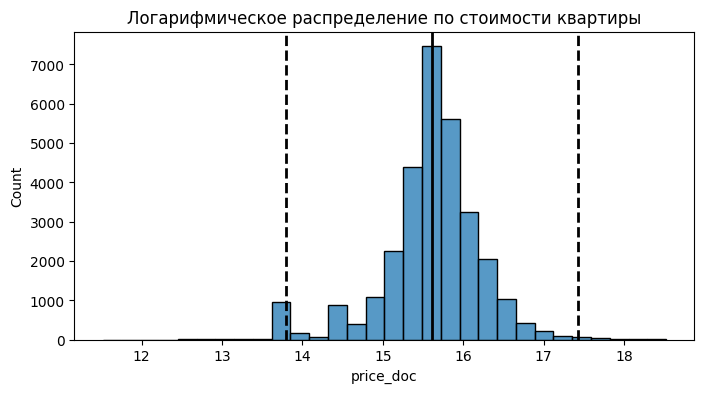

In [188]:
fig, ax = plt.subplots(1, 1, figsize = (8,4))
log_price = np.log(sber_data_copy['price_doc']+1)
histplot = sns.histplot(log_price, bins=30, axes=ax)
histplot.axvline(log_price.mean(), color = 'k', lw =2)
histplot.axvline(log_price.mean() + 3 * log_price.std(), color = 'k', ls = '--',lw =2)
histplot.axvline(log_price.mean() - 3 * log_price.std(), color = 'k', ls = '--',lw =2)
histplot.set_title('Логарифмическое распределение по стоимости квартиры')

Задание 6.6


Найдите потенциальные выбросы по признаку price_doc с помощью метода z-отклонения. Используйте логарифмический масштаб распределения. Сделайте «послабление» на 0.7 сигм в обе стороны распределения. Сколько выбросов вы получили?

In [193]:
def outliers_z_scores_mod_2(data, feature, log_scale = False, left =3, right = 3): 
    if log_scale: x = np.log(data[feature]+1)
    else: x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left*sigma
    upper_bound = mu + right*sigma
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned 


# Применим эту функцию к таблице sber_data и признаку mkad_km, а также выведем размерности результатов: 

outliers_5, cleaned_5=outliers_z_scores_mod_2(data = sber_data_copy, feature = 'price_doc',log_scale=True,left = 3.7, right = 3.7)
print(f'Число выбросов по методу z- отклонений: {outliers_5.shape[0]}')
print(f'Результирующее число записей: {cleaned_5.shape[0]}')

Число выбросов по методу z- отклонений: 52
Результирующее число записей: 30419


Задание 6.7


Добавьте фишку с логарифмированием в свою функцию outliers_iqr_mod(). Добавьте в неё параметр log_scale. Если он выставлен в True, то производится логарифмирование признака. Примените полученную функцию к признаку price_doc. Число межквартильных размахов в обе стороны обозначьте как 3. Чему равно число выбросов, полученных таким методом?

При логарифмировании признака price_doc добавлять к нему 1 не нужно, он не имеет нулевых значений!

In [202]:
def outliers_iqr_mod_3(data,feature,log_scale = False, left=1.5,right=1.5): 
    if log_scale: x = np.log(data[feature])
    else: x = data[feature]
    
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr  = quartile_3 - quartile_1 
    lower_bound = quartile_1 - (iqr*left)
    upper_bound = quartile_3 + (iqr*right)
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned
outliers_3, cleaned_3=outliers_iqr_mod_3(data = sber_data_copy, feature = 'price_doc',log_scale = True, left=3.0,right=3.0)
print(f'Число выбросов по методу Тьюки: {outliers_3.shape[0]}')
print(f'Результирующее число записей: {cleaned_3.shape[0]}')

Число выбросов по методу Тьюки: 92
Результирующее число записей: 30379


### 7. Работа с дубликатами и неинформативными признаками

✍️ Проверим, есть у нас такие записи: для этого сравним число уникальных значений в столбце id с числом строк. Число уникальных значений вычислим с помощью метода nunique():

In [5]:
sber_data_copy['id'].nunique()==sber_data_copy.shape[0]

True

✍️ Найдём число полных дубликатов таблице sber_data. Предварительно создадим список столбцов dupl_columns, по которым будем искать совпадения (все столбцы, не включая id). 

Создадим маску дубликатов с помощью метода duplicated() и произведём фильтрацию. Результат заносим в переменную sber_duplicates. Выведем число строк в результирующем DataFrame:

In [8]:
dupl_columns = list(sber_data_copy.columns)
dupl_columns.remove('id')
mask= sber_data_copy.duplicated(subset=dupl_columns)
sber_duplicates = sber_data_copy[mask]
print(f'Число найденных дубликатов: {sber_duplicates.shape[0]}')

Число найденных дубликатов: 562


Итак, 562 строки в таблице являются полными копиями других записей. Ручной поиск совпадающих строк по 30 тысячам записей был бы практически невыполним, а с помощью pandas мы быстро, а главное, легко обнаружили дублирующиеся данные!

✍️ Создадим новую таблицу sber_dedupped, которая будет версией исходной таблицы, очищенной от полных дубликатов.

In [9]:
sber_dedupped = sber_data_copy.drop_duplicates(subset=dupl_columns)
print(f'Результирующие число записей: {sber_dedupped.shape[0]}')

Результирующие число записей: 29909


#### Неинформативные признаки

Отсутствием новой и полезной информации могут «похвастаться» не только отдельные записи в таблице, но и целые признаки.

Неинформативными называются признаки, в которых большая часть строк содержит одинаковые значения (например, пол клиентов в мужском барбершопе), либо наоборот — признак, в котором для большинства записей значения уникальны (например, номер телефона клиента). 

Мы уже сталкивались с неинформативными признаками. Вспомните датасет о домах в Мельбурне, где был признак адреса дома с уникальным значением для каждого дома. 

Обнаружение и ликвидация неинформативных признаков


Чтобы считать признак неинформативным, прежде всего нужно задать какой-то определённый порог. Например, часто используют пороги в 0.95 и 0.99. Это означает: признак неинформативен, если в нем 95 % (99 %) одинаковых значений или же 95 % (99 %) данных полностью уникальны.

К сожалению, в pandas пока нет волшебной палочки, которая мгновенно бы выдавала список столбцов, обладающих низкой информативностью. Однако процедура их поиска легко реализуется вручную.

Разберём алгоритм:

→ Создаём пустой список low_information_cols, куда будем добавлять названия признаков, которые мы посчитаем неинформативными.

→ В цикле пройдёмся по всем именам столбцов в таблице и для каждого будем совершать следующие действия:

рассчитаем top_freq — наибольшую относительную частоту с помощью метода value_counts() с параметром normalize=True. Метод вернёт долю от общих данных, которую занимает каждое уникальное значение в признаке.
Например, для столбца oil_chemistry_raion (нефтехимический район) результат будет следующим:



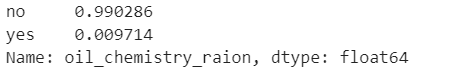


Отсюда нам нужен максимум.

рассчитаем nunique_ratio — отношение числа уникальных значений в столбце к размеру всего столбца. Число уникальных значений в столбце получим с помощью метода nunique(), а размер признака — с помощью метода count(). Например, для столбца id число уникальных значений — 30471; оно же равно размеру таблицы. Поэтому результат отношения будет 1.
сравним каждое из полученных чисел с пороговым значением (у нас это 0.95) и добавим в список неинформативных признаков, если условие истинно.

In [12]:
# список неинформативных признаков 
low_information_cols = []

# цикл по всем стобцам 
for col in sber_data_copy.columns: 
    # наибольшая относительная частота в признаке 
    top_freq = sber_data_copy[col].value_counts(normalize=True).max()
    # доля уникальных значений от размера признака 
    nunique_ratio = sber_data_copy[col].nunique()/sber_data_copy[col].count()
    # сравнимаем наибольшую частоту с порогом 
    if top_freq > 0.95: 
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом 
    if nunique_ratio > 0.95: 
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')

id: 100.0% уникальных значений
oil_chemistry_raion: 99.03% одинаковых значений
railroad_terminal_raion: 96.27% одинаковых значений
nuclear_reactor_raion: 97.17% одинаковых значений
big_road1_1line: 97.44% одинаковых значений
mosque_count_1000: 98.08% одинаковых значений


Итак, мы нашли шесть неинформативных признаков. Теперь можно удалить их с помощью метода drop(), передав результирующий список в его аргументы.

In [14]:
information_sber_data = sber_data_copy.drop(low_information_cols, axis = 1)
print(f'Результирующее число признаков: {information_sber_data.shape[1]}')

Результирующее число признаков: 55


### 8. Закрепление знаний

Этот набор данных создан для того, чтобы на основе определённых диагностических измерений предсказать, есть ли у пациента диабет. 

На выбор этих экземпляров из более крупной базы данных было наложено несколько ограничений. В частности, все пациенты здесь — женщины не моложе 21 года индейского происхождения Пима.

Pregnancies — количество беременностей.

Glucose — концентрация глюкозы в плазме через два часа при пероральном тесте на толерантность к глюкозе.

BloodPressure — диастолическое артериальное давление (мм рт. ст.).

SkinThickness — толщина кожной складки трицепса (мм).

Insulin — двухчасовой сывороточный инсулин (ме Ед/мл).

BMI — индекс массы тела (вес в кг / рост в м2).

DiabetesPedigreeFunction — функция родословной диабета (чем она выше, тем выше шанс наследственной 
заболеваемости).

Age — возраст.

Outcome — наличие диабета (0 — нет, 1 — да).

In [92]:
import pandas as pd
diabetes = pd.read_csv('diabetes_data.csv')
diabetes['Outcome'].value_counts()

Outcome
0    510
1    268
Name: count, dtype: int64

Задание 8.1
1 point possible (graded)
Начнём с поиска дубликатов в данных. Найдите все повторяющиеся строки в данных и удалите их. Для поиска используйте все признаки в данных. Сколько записей осталось в данных?

In [93]:
dupl_columns_diabet = list(diabetes.columns)

mask_diabet= diabetes.duplicated(subset=dupl_columns_diabet)

diabetes_duplicates = diabetes[mask_diabet]
#diabetes_duplicates
print(f'Число найденных дубликатов: {diabetes_duplicates.shape[0]}')

Число найденных дубликатов: 10


Задание 8.2
Далее найдите все неинформативные признаки в данных и избавьтесь от них. В качестве порога информативности возьмите 0.95: удалите все признаки, для которых 95 % значений повторяются или 95 % записей уникальны. В ответ запишите имена признаков, которые вы нашли (без кавычек

In [94]:
# список неинформативных признаков 
low_information_cols_2 = []

# цикл по всем стобцам 
for col in diabetes.columns: 
    # наибольшая относительная частота в признаке 
    top_freq_diabet = diabetes[col].value_counts(normalize=True).max()
    # доля уникальных значений от размера признака 
    nunique_ratio_diabet= diabetes[col].nunique()/diabetes[col].count()
    # сравнимаем наибольшую частоту с порогом 
    if top_freq_diabet > 0.95: 
        low_information_cols_2.append(col)
        print(f'{col}: {round(top_freq_diabet*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом 
    if nunique_ratio_diabet > 0.95: 
        low_information_cols_2.append(col)
        print(f'{col}: {round(nunique_ratio_diabet*100, 2)}% уникальных значений')
        
diabetes = diabetes.drop(['Gender'], axis=1)

Gender: 100.0% одинаковых значений


Задание 8.3

Попробуйте найти пропуски в данных с помощью метода isnull().

Спойлер: ничего не найдёте. А они есть! Просто они скрыты от наших глаз. В таблице пропуски в столбцах Glucose, BloodPressure, SkinThickness, Insulin и BMI обозначены нулём, поэтому традиционные методы поиска пропусков ничего вам не покажут. Давайте это исправим!

Замените все записи, равные 0, в столбцах Glucose, BloodPressure, SkinThickness, Insulin и BMI на символ пропуска. Его вы можете взять из библиотеки numpy: np.nan.

Какая доля пропусков содержится в столбце Insulin? Ответ округлите до сотых.

In [95]:
import numpy as np
diabetes['Insulin'] = diabetes['Insulin'].apply(lambda d: np.nan if d==0 else d)
diabetes['Glucose'] = diabetes['Glucose'].apply(lambda d: np.nan if d==0 else d)
diabetes['SkinThickness'] = diabetes['SkinThickness'].apply(lambda d: np.nan if d==0 else d)
diabetes['BloodPressure'] = diabetes['BloodPressure'].apply(lambda d: np.nan if d==0 else d)
diabetes['BMI'] = diabetes['BMI'].apply(lambda d: np.nan if d==0 else d)

diabetes['Insulin'].info()

<class 'pandas.Series'>
RangeIndex: 778 entries, 0 to 777
Series name: Insulin
Non-Null Count  Dtype  
--------------  -----  
398 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [96]:
display(diabetes['Insulin'].isnull().mean().round(2))
display(diabetes['Glucose'].isnull().mean().round(2))
display(diabetes['SkinThickness'].isnull().mean().round(2))
display(diabetes['BloodPressure'].isnull().mean().round(2))
display(diabetes['BMI'].isnull().mean().round(2))
display(diabetes['Pregnancies'].isnull().mean().round(2))
display(diabetes['DiabetesPedigreeFunction'].isnull().mean().round(2))
display(diabetes['Outcome'].isnull().mean().round(2))

np.float64(0.49)

np.float64(0.01)

np.float64(0.3)

np.float64(0.05)

np.float64(0.01)

np.float64(0.0)

np.float64(0.0)

np.float64(0.0)

In [97]:
diabetes = diabetes.drop(['Insulin'], axis=1)

Задание 8.5

Удалите из данных только те строки, в которых содержится более двух пропусков одновременно. Чему равно результирующее число записей в таблице?

In [120]:
diabetes = diabetes.dropna(thresh=6,axis=0)
print(diabetes.shape[0])

771


Задание 8.6

В оставшихся записях замените пропуски на медиану. Чему равно среднее значение в столбце SkinThickness? Ответ округлите до десятых.

In [184]:
diabetes_1 = diabetes.copy()

In [ ]:
# полез по старинке делать через функцию. оказалось, что есть гораздо проще код. 
# в этой ячейки код так до конца и не доделан. 

def change_nan(data):
    for col in data.columns:
         med = data[col].median()
         for value in data[col]:
             if pd.isna(value): 
                 data.loc[value,col] = med
             
    return data

diabetes_1 = change_nan(diabetes_1)
#diabetes_1 = diabetes_1.apply(change_nan)
#diabetes_1['SkinThickness'] =change_nan_column(diabetes_1['SkinThickness'])
#diabetes['Glucose'] = diabetes['Glucose'].apply(lambda d: diabetes['Glucose'].median() if d==None else d)

#diabetes['SkinThickness'] = diabetes['SkinThickness'].apply(lambda d: diabetes['SkinThickness'].median() if d==0 else d)
#diabetes['BloodPressure'] = diabetes['BloodPressure'].apply(lambda d: np.nan if d==0 else d)
#diabetes['BMI'] = diabetes['BMI'].apply(lambda d: np.nan if d==0 else d)

In [191]:
# правильный код по выполнению задания 
# составляем сначала словарь с тем, какие у нас соответствия на каждую колонку должны быть, 
# в отношении отсутствующих значений 
values = {'Pregnancies':diabetes_1['Pregnancies'].median(), 
          'Glucose':diabetes_1['Glucose'].median(), 
          'BloodPressure':diabetes_1['BloodPressure'].median(),
          'SkinThickness':diabetes_1['SkinThickness'].median(), 
          'BMI':diabetes_1['BMI'].median(), 
          'DiabetesPedigreeFunction':diabetes_1['DiabetesPedigreeFunction'].median(), 
          'Age':diabetes_1['Age'].median(), 
          'Outcome':diabetes_1['Outcome'].median()}
# тут обновляем датафрейм и заполняем пропуски значениями из словаря 
diabetes_1 =diabetes_1.fillna(values)

# отвечаем на вопрос задания, находим среднее значение по колонке SkinThickness 
diabetes_1['SkinThickness'].describe()

count    771.000000
mean      29.106355
std        8.785561
min        7.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

Задание 8.7

Сколько выбросов найдёт классический метод межквартильного размаха в признаке SkinThickness?

In [192]:
def outliers_iqr_diabetes(data,feature): 
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr  = quartile_3 - quartile_1 
    lower_bound = quartile_1 - (iqr*1.5)
    upper_bound = quartile_3 + (iqr*1.5)
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned

In [193]:
outliers_diabetes, cleaned_diabetes = outliers_iqr_diabetes(diabetes_1, 'SkinThickness')
print(f'Число выбросов по методу Тьюки: {outliers_diabetes.shape[0]}')
print(f'Результирующее число записей: {cleaned_diabetes.shape[0]}')

Число выбросов по методу Тьюки: 87
Результирующее число записей: 684


Задание 8.8

Сколько выбросов найдёт классический метод z-отклонения в признаке SkinThickness?



In [203]:
def outliers_z_scores_diabetes(data, feature, log_scale = False): 
    if log_scale: x = np.log(data[feature]+1)
    else: x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - 3*sigma
    upper_bound = mu + 3*sigma
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    cleaned = data[(x>=lower_bound)&(x<=upper_bound)]
    return outliers, cleaned 


# Применим эту функцию к таблице sber_data и признаку mkad_km, а также выведем размерности результатов: 

outliers_diabetes, cleaned_diabetes=outliers_z_scores_diabetes(data = diabetes_1, feature = 'SkinThickness')
print(f'Число выбросов по методу z- отклонений: {outliers_diabetes.shape[0]}')
print(f'Результирующее число записей: {cleaned_diabetes.shape[0]}')

Число выбросов по методу z- отклонений: 4
Результирующее число записей: 767


Задание 8.9

На приведённой гистограмме показано распределение признака DiabetesPedigreeFunction. Такой вид распределения очень похож на логнормальный, и он заставляет задуматься о логарифмировании признака. Найдите сначала число выбросов в признаке DiabetesPedigreeFunction с помощью классического метода межквартильного размаха.

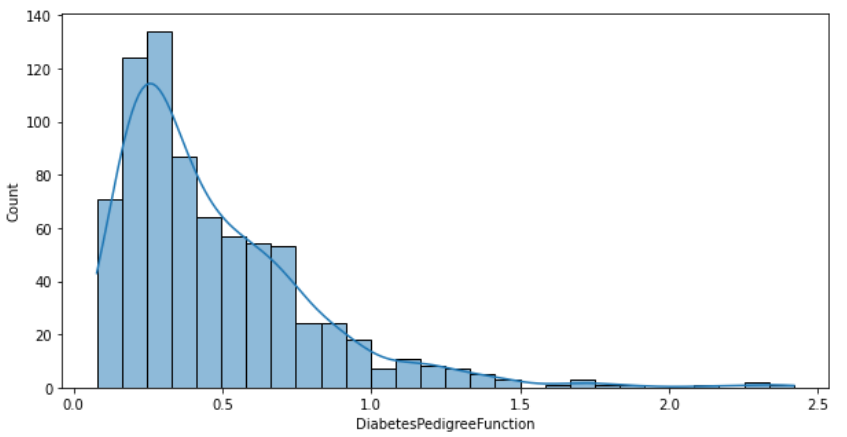

Затем найдите число выбросов в этом же признаке в логарифмическом масштабе (при логарифмировании единицу прибавлять не нужно!). Какова разница между двумя этими числами (вычтите из первого второе)?

Решение, часть 1: Находим выбросы через межквартильный размах

In [227]:
def outliers_z_scores_mod_diabetes(data, feature, log_scale = False, left =1.5, right = 1.5): 
    if log_scale: x = np.log(data[feature])
    else: x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr  = quartile_3 - quartile_1 
    lower_bound = quartile_1 - (iqr*left)
    upper_bound = quartile_3 + (iqr*right)
    outliers = data[(x<lower_bound)|(x>upper_bound)]
    return outliers

outliers_mod=outliers_z_scores_mod_diabetes(data = diabetes_1, feature = 'DiabetesPedigreeFunction')
outliers_mod_1=outliers_z_scores_mod_diabetes(data = diabetes_1, feature = 'DiabetesPedigreeFunction', log_scale=True)
print(outliers_mod.shape[0]-outliers_mod_1.shape[0])


29


In [195]:
diabetes_1


,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,98.0,58.0,33.0,34.0,0.430,43,0
1,2,112.0,75.0,32.0,35.7,0.148,21,0
2,2,108.0,64.0,29.0,30.8,0.158,21,0
3,8,107.0,80.0,29.0,24.6,0.856,34,0
4,7,136.0,90.0,29.0,29.9,0.210,50,0
...,...,...,...,...,...,...,...,...
773,6,103.0,72.0,32.0,37.7,0.324,55,0
774,1,71.0,48.0,18.0,20.4,0.323,22,0
775,0,117.0,72.0,29.0,33.8,0.932,44,0
776,4,154.0,72.0,29.0,31.3,0.338,37,0
